In [2]:
# CNN

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import cv2

from PIL import Image
import os
import time
import seaborn as sns

from sklearn.metrics import confusion_matrix
from torchsummary import summary

import torch.nn.utils.prune as prune

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
class SimpleDNN(nn.Module):
    def __init__(self):
        super(SimpleDNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

dnn_model = SimpleDNN()
print(dnn_model)

test_input = torch.randn(1, 1, 28, 28)
dnn_output = dnn_model(test_input)
print(dnn_output.shape)

SimpleDNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
torch.Size([1, 10])


In [4]:
sobel_filter = torch.tensor([[[
    [1.0, 0.0, -1.0],
    [2.0, 0.0, -2.0],
    [1.0, 0.0, -1.0]
]]])

sample_28X28 = torch.randn(1, 1, 28, 28)
sobel_output = nn.functional.conv2d(sample_28X28, sobel_filter)
print(sobel_output.shape)

torch.Size([1, 1, 26, 26])


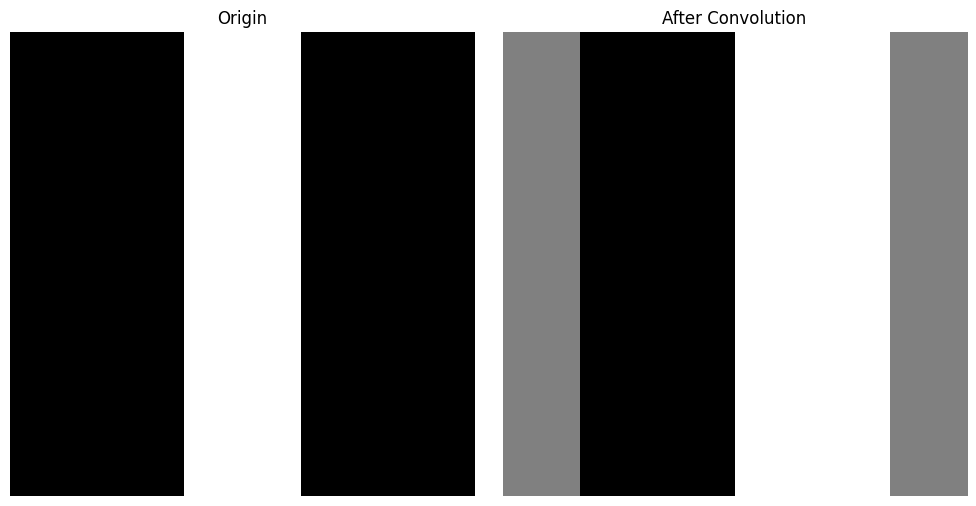

In [5]:
filter_2d = torch.tensor([[
    [1.0, 0.0, -1.0],
    [1.0, 0.0, -1.0],
    [1.0, 0.0, -1.0]
]]).unsqueeze(0)

sample_image_2 = torch.zeros(1, 1, 8, 8)
sample_image_2[0, 0, :, 3:5] = 1.0

output_2 = nn.functional.conv2d(sample_image_2, filter_2d)

plt.figure(figsize = (10,5))
plt.subplot(1, 2, 1)
plt.imshow(sample_image_2[0, 0].numpy(), cmap = "gray")
plt.title("Origin")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(output_2[0, 0].detach().numpy(), cmap = "gray") #detach: 거쳐온 conv2d 필터를 없애고 출력하겠다.
plt.title("After Convolution")
plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
input_image = torch.randn(1, 1, 6, 6)
filter1 = torch.randn(1, 1, 3, 3)

# 출력 = {(입력 - 커널 + 2 * 패딩) / 스트라이드} + 1
output1 = F.conv2d(input_image, filter1, stride = 1, padding = 0)
print(output1.shape)

output2 = F.conv2d(input_image, filter1, stride = 1, padding = 1)
print(output2.shape)

output3 = F.conv2d(input_image, filter1, stride = 2, padding = 0)
print(output3.shape)

torch.Size([1, 1, 4, 4])
torch.Size([1, 1, 6, 6])
torch.Size([1, 1, 2, 2])


In [7]:
input_rgb = torch.randn(1, 3, 32, 32)
filters = torch.randn(16, 3, 3, 3)

output4 = F.conv2d(input_rgb, filters, stride = 1, padding = 1)
print(output4.shape)

torch.Size([1, 16, 32, 32])


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16,
                               kernel_size = 3, stride = 1, padding = 1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32,
                               kernel_size = 3, stride = 1, padding = 1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.fc = nn.Linear(2048, 10)

    def forward(self, x):
        # 첫 번째 블록
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        # 두 번째 블록
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

model = SimpleCNN()
print(model)

sample_input = torch.randn(1, 3, 32, 32)
output = model(sample_input)
print(output)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=2048, out_features=10, bias=True)
)
tensor([[ 0.0485,  0.2012, -0.2908, -0.2598, -0.0998,  0.2819, -0.2126, -0.5539,
          0.0512, -0.0537]], grad_fn=<AddmmBackward0>)


In [9]:
class CNNBatchNorm(nn.Module):
    def __init__(self):
        super(CNNBatchNorm, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16,
                               kernel_size = 3, stride = 1, padding = 1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32,
                               kernel_size = 3, stride = 1, padding = 1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.fc = nn.Linear(2048, 10)

    def forward(self, x):
        # 첫 번째 블록
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        # 두 번째 블록
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

model = CNNBatchNorm()
print(model)

sample_input = torch.randn(1, 3, 32, 32)
output = model(sample_input)
print(output)

CNNBatchNorm(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=2048, out_features=10, bias=True)
)
tensor([[-0.2958,  0.4415,  0.6549, -0.4911,  1.2007, -0.5548,  0.1569,  1.0605,
          0.3198,  1.3474]], grad_fn=<AddmmBackward0>)


In [10]:
class CNNDropout(nn.Module):
    def __init__(self):
        super(CNNDropout, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16,
                               kernel_size = 3, stride = 1, padding = 1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.dropout1 = nn.Dropout(0.25)

        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32,
                               kernel_size = 3, stride = 1, padding = 1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.dropout2 = nn.Dropout(0.25)

        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.dropout3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # 첫 번째 블록
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        # 두 번째 블록
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.dropout2(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.dropout3(x)
        x = self.fc2(x)

        return x

model = CNNDropout()
print(model)

sample_input = torch.randn(1, 3, 32, 32)
output = model(sample_input)
print(output)

CNNDropout(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (dropout3): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
tensor([[ 0.5051, -0.5934,  0.0689,  0.3743,  0.9188, -0.0506,  0.4704, -0.0572,
          0.6121,  1.2938]], grad_fn=<AddmmBackward0>)


In [11]:
transform_train = transforms.Compose(
    [
        # 데이터 증강
        transforms.RandomCrop(32, padding = 4),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15), # 랜덤 회전
        transforms.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2), # 밝기, 대비, 등 색 변화
        # 데이터 텐서화
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ]
)

# 테스트 데이터는 증강하면 안됨.
transform_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ]
)

try:
    train_dataset = torchvision.datasets.CIFAR10(root = "./data", train = True, download = True, transform = transform_train)
    test_dataset = torchvision.datasets.CIFAR10(root= "./data", train = False, download = True, transform = transform_test)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 128, shuffle = True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 100, shuffle = False)

    print(len(train_dataset))
    print(len(test_dataset))

except Exception as e:
    print(f"오류 발생 {e}")


100%|██████████| 170M/170M [25:41<00:00, 111kB/s]  


50000
10000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.5632443].


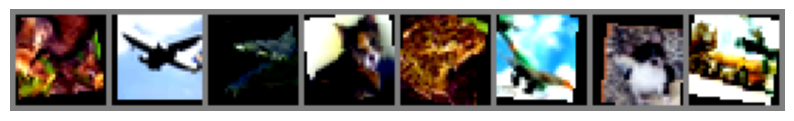

<generator object <genexpr> at 0x000001B753A780B0>
torch.Size([3, 32, 32])
128
10


In [12]:
classes = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.figure(figsize = (10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

try:
    dataiter = iter(train_loader)
    images, labels = next(dataiter)
    imshow(torchvision.utils.make_grid(images[:8]))
    print(classes[labels[j]] for j in range(8))
    print(images[0].shape) # 이미지 크기
    print(images.shape[0]) # 배치사이즈
    print(len(classes))

except Exception as e:
    print(f"오류발생 {e}")

In [13]:
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN,self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace = True),
            nn.Conv2d(32, 32, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(64), 
            nn.ReLU(inplace = True),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace = True),
            nn.Conv2d(128, 128, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.Dropout2d(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(inplace = True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [15]:
cifar_model = CIFAR10_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
print(cifar_model)

cifar_params = sum(p.numel() for p in cifar_model.parameters())

print(cifar_params)
print(device)

CIFAR10_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout2d(p=0.25, inplace=False)
    (13): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): BatchNorm2d

In [16]:
# 학습 함수 정의

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(train_loader):
        if i >= 10:
            break

        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if i % 5 == 4:
            print(f"Batch: {i + 1}, Loss: {running_loss / (i + 1)}, Accuracy: {100 * correct / total}")

    return running_loss / min(i + 1 ,10), 100 * correct / total

def evaluate_model(model, test_loader, criterion, optimizer, device):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            if i >= 5 :
                break

            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return test_loss / (i + 1), 100 * correct / total


In [17]:
try:
    if "train_loader" in locals():
        for epoch in range(10):
            print(f"epoch: {epoch + 1}")
            train_loss, train_Acc = train_epoch(cifar_model, train_loader, criterion, optimizer, device)

        test_loss, test_acc = evaluate_model(cifar_model, test_loader, criterion, optimizer, device)

        print(f"Test Loss: {test_loss}, Test Acc: {test_acc}")

    else:
        print("Data Not Prepared!")

except Exception as e:
    print(f"오류 발생 {e}")

epoch: 1
Batch: 5, Loss: 2.3922871589660644, Accuracy: 10.0
Batch: 10, Loss: 2.388793134689331, Accuracy: 9.53125
epoch: 2
Batch: 5, Loss: 2.4056327819824217, Accuracy: 10.46875
Batch: 10, Loss: 2.388509464263916, Accuracy: 10.390625
epoch: 3
Batch: 5, Loss: 2.395400857925415, Accuracy: 11.09375
Batch: 10, Loss: 2.3955801486968995, Accuracy: 10.3125
epoch: 4
Batch: 5, Loss: 2.4320912837982176, Accuracy: 8.4375
Batch: 10, Loss: 2.405538773536682, Accuracy: 10.15625
epoch: 5
Batch: 5, Loss: 2.408030462265015, Accuracy: 9.21875
Batch: 10, Loss: 2.4068336725234984, Accuracy: 9.21875
epoch: 6
Batch: 5, Loss: 2.4109540939331056, Accuracy: 10.0
Batch: 10, Loss: 2.404585599899292, Accuracy: 10.0
epoch: 7
Batch: 5, Loss: 2.3989251136779783, Accuracy: 9.6875
Batch: 10, Loss: 2.414792704582214, Accuracy: 8.59375
epoch: 8
Batch: 5, Loss: 2.419431447982788, Accuracy: 8.28125
Batch: 10, Loss: 2.405733060836792, Accuracy: 8.90625
epoch: 9
Batch: 5, Loss: 2.4018070697784424, Accuracy: 10.46875
Batch: 

In [18]:
# ResNet

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Skip Connection (차원이 변경될 경우 1×1 합성곱으로 조정)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(residual)   # Skip Connection
        out = self.relu(out)
        return out

residual_block = ResidualBlock(64, 64)
test_input = torch.randn(1, 64, 32, 32)
residual_output = residual_block(test_input)
print(residual_output.shape)
print(test_input.shape)

torch.Size([1, 64, 32, 32])
torch.Size([1, 64, 32, 32])


In [20]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )
    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(residual)  # Skip Connection
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

def ResNet18(num_classes=10):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)

def ResNet34(num_classes=10):
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes)

resnet18_model = ResNet18(num_classes=10)
resnet_params = sum(p.numel() for p in resnet18_model.parameters())
print(resnet_params)

test_input = torch.randn(1, 3, 32, 32)
resnet_output = resnet18_model(test_input)
print(resnet_output.shape)

11173962
torch.Size([1, 10])


In [21]:
# Scheduler

from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, CosineAnnealingLR
demo_model = SimpleCNN()
demo_optimizer = optim.SGD(demo_model.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 5e-4)
step__scheduler = StepLR(demo_optimizer, step_size = 30, gamma = 0.1)
plateau_scheduler = ReduceLROnPlateau(demo_optimizer, mode ='min', factor = 0.1, patience = 10)
cosine_scheduler = CosineAnnealingLR(demo_optimizer, T_max = 200)

def initializer_weight(model, init_type = 'kaiming'):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            if init_type == 'kaiming':
                nn.init.kaiming_normal_(m.weight, mode = 'fan_out', nonlinearity = 'relu')
            elif init_type == 'xavier':
                nn.init.xavier_normal_(m.weight)
            elif init_type == 'normal':
                nn.init.normal_(m.weight, mean = 0, std = 0.01)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.Linear):
            if init_type == 'kaiming':
                nn.init.kaiming_normal_(m.weight, mode = 'fan_out', nonlinearity = 'relu')
            elif init_type == 'xavier':
                nn.init.xavier_normal_(m.weight)
            elif init_type == 'normal':
                nn.init.normal_(m.wiehgt, mean = 0, std = 0.01)
                nn.init.constant_(m.bias, 0)
initializer_weight(demo_model, 'kaiming')